# 1. 데이터 준비

In [3]:
# 기본 라이브러리
import pandas as pd
import numpy as np

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (맷플롯립)
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'  # Windows 환경
matplotlib.rcParams['axes.unicode_minus'] = False

# 전처리 및 분할
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline

# 모델 정의
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# 평가지표 및 시각화 도구
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)

# 기타 설정
import warnings
warnings.filterwarnings('ignore')


In [4]:
# 데이터 불러오기
file_path = r"D:\python\코드잇 스프린트 데분\codeit-sprint-projects\sprint-missions\스프린트 미션 13\data\processed\bank_cleaned.csv"
df = pd.read_csv(file_path)

# 특성과 타겟 분리
X = df.drop('y', axis=1)
y = df['y']
X = X.drop(columns='duration_group')

# 데이터 크기 확인
print(f"전체 데이터 크기: {df.shape}")
print(f"입력 변수 X: {X.shape}")
print(f"타겟 변수 y: {y.shape}")


전체 데이터 크기: (41188, 55)
입력 변수 X: (41188, 53)
타겟 변수 y: (41188,)


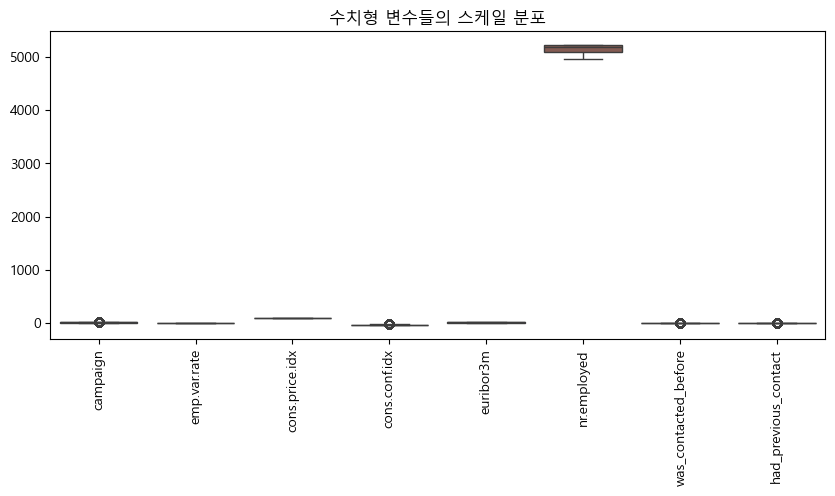

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 수치형 변수만 추출
numeric_cols = X.select_dtypes(include=['float64', 'int64']).columns

# 스케일 분포 시각화
plt.figure(figsize=(10, 4))
sns.boxplot(data=X[numeric_cols])
plt.xticks(rotation=90)
plt.title('수치형 변수들의 스케일 분포')
plt.show()


In [6]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import StratifiedKFold

# 수치형 변수만 스케일링
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
scaler = MinMaxScaler()
X_scaled = X.copy()
X_scaled[numeric_cols] = scaler.fit_transform(X[numeric_cols])

# Stratified K-Fold 셋업
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 분포 확인 (선택)
print("타겟 클래스 분포:")
print(y.value_counts(normalize=True))


타겟 클래스 분포:
y
0    0.887346
1    0.112654
Name: proportion, dtype: float64


# 2. 정리

| 단계 | 작업 내용                                            | 목적                                                                           |
| -- | ------------------------------------------------ | ---------------------------------------------------------------------------- |
| 1  | **스케일링 (선택)**                                    | 일부 모델의 경우 정규화가 필요 (예: SVM, 로지스틱 회귀 등). `MinMaxScaler` 또는 `StandardScaler` 적용 |
| 2  | **Stratified K-Fold 교차 검증 셋업**                   | 타겟 클래스 불균형을 고려한 안정적인 교차검증 기반 성능 비교                                           |
| 3  | **여러 모델 정의**                                     | 로지스틱 회귀, 결정 트리, 랜덤 포레스트, XGBoost, LightGBM 등 8개 이상 모델 정의                     |
| 4  | **각 모델에 대해 교차 검증 수행**                            | 성능 지표(accuracy, precision, recall, F1, ROC AUC 등)를 모두 수집                     |
| 5  | **모델별 성능 비교 및 시각화**                              | 모델별 교차검증 결과를 표나 그래프로 정리하여 우수 모델 후보 선정                                        |
| 6  | **상위 모델 튜닝(GridSearchCV 또는 RandomizedSearchCV)** | ROC AUC 또는 F1 기준으로 최적 하이퍼파라미터 탐색                                             |
| 7  | **최종 모델 성능 평가**                                  | confusion matrix, classification report, ROC curve, PR curve 시각화             |
| 8  | **Feature Importance 분석**                        | tree 계열 모델의 feature importance 또는 SHAP 등으로 해석 가능성 확보                         |
| 9  | **전략 인사이트 도출**                                   | 모델 분석을 바탕으로 마케팅 대상자, 시기, 특성 등 캠페인 전략 제안                                      |


# 3. 모델 정의

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# 모델 정의
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1)
}


# 4. 교차검증 기반 성능 비교

In [8]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

# 평가 지표 설정
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'f1': make_scorer(f1_score),
    'roc_auc': make_scorer(roc_auc_score)
}

# Stratified K-Fold 설정
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 결과 저장용 딕셔너리
results = {}

# 교차검증 실행
for name, model in models.items():
    print(f"교차검증 시작: {name}")
    cv_result = cross_validate(model, X_scaled, y, cv=skf, scoring=scoring, return_train_score=False, n_jobs=-1)
    results[name] = {metric: round(cv_result[f'test_{metric}'].mean(), 4) for metric in scoring.keys()}


교차검증 시작: Logistic Regression
교차검증 시작: Decision Tree
교차검증 시작: Random Forest
교차검증 시작: XGBoost


In [9]:
# 결과 정리
results_df = pd.DataFrame(results).T.sort_values(by='roc_auc', ascending=False)
results_df


,accuracy,precision,recall,f1,roc_auc
XGBoost,0.8968,0.5865,0.2843,0.3825,0.6294
Random Forest,0.8892,0.5146,0.2929,0.3731,0.6289
Decision Tree,0.8475,0.3302,0.3442,0.3370,0.6278
Logistic Regression,0.9000,0.6628,0.2276,0.3384,0.6065


### 클레스 불균형 처리

In [15]:
# 필요 라이브러리
from imblearn.over_sampling import SMOTE

# SMOTE 인스턴스 생성
smote = SMOTE(random_state=42)

# 클래스 불균형 보정
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

# 확인
print("Before SMOTE:", y.value_counts(normalize=True))
print("After SMOTE:", y_resampled.value_counts(normalize=True))


Before SMOTE: y
0    0.887346
1    0.112654
Name: proportion, dtype: float64
After SMOTE: y
0    0.5
1    0.5
Name: proportion, dtype: float64


In [16]:
# 동일한 모델 정의
models = {
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42)
}

# 결과 저장용
results = []

# 교차검증 진행
for name, model in models.items():
    scores = cross_validate(
        model,
        X_resampled,
        y_resampled,
        cv=5,
        scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
        n_jobs=-1
    )
    
    result = {
        'model': name,
        'accuracy': np.mean(scores['test_accuracy']),
        'precision': np.mean(scores['test_precision']),
        'recall': np.mean(scores['test_recall']),
        'f1': np.mean(scores['test_f1']),
        'roc_auc': np.mean(scores['test_roc_auc'])
    }
    
    results.append(result)

# 데이터프레임으로 정리
cv_results_smote = pd.DataFrame(results).set_index('model')
display(cv_results_smote)


,accuracy,precision,recall,f1,roc_auc
model,,,,,
XGBoost,0.518828,0.510058,0.864265,0.640261,0.566133
Random Forest,0.559103,0.537050,0.932201,0.680400,0.520342
Decision Tree,0.519251,0.509237,0.908754,0.652101,0.514346
Logistic Regression,0.556405,0.550719,0.744283,0.628266,0.651028


### ❌ 소폭 오버샘플링 + 클래스 가중치 조합 (실험 실패)

- **도전 배경**  
  SMOTE를 통해 1 클래스 비율을 50%까지 맞추는 방식이 너무 인위적일 수 있다는 우려로,  
  보다 현실적인 분포(약 25~30%) 수준에서 소폭 오버샘플링을 적용하고  
  동시에 `class_weight='balanced'`로 모델이 불균형을 학습하도록 유도함.

- **실험 결과**  
  - `precision`, `f1`, `roc_auc` 등 주요 지표가 모두 **기존 SMOTE(50:50)** 실험보다 낮게 나옴  
  - 특히 precision이 전반적으로 0.2~0.3 수준으로 떨어지며 **과도한 false positive** 발생  
  - 모델별 성능 편차 없이 전반적으로 **신뢰도 낮은 예측 경향**

- **결론**  
  이 조합은 예상과 달리 성능 개선 효과가 없어 **사용하지 않기로 결정함**.  
  대신 SMOTE 50:50 기반 결과를 바탕으로 **threshold 조정 등 후속 전략**을 고려하기로 함.


#### 1. Threshold 조정 실험

In [21]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import pandas as pd

# threshold 리스트
thresholds = [0.5, 0.4, 0.35, 0.3]

# 모델 리스트
models = {
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

# 결과 저장
results = []

# 교차검증 준비
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 모델별 루프
for model_name, model in models.items():
    for threshold in thresholds:
        precision_list = []
        recall_list = []
        f1_list = []
        roc_auc_list = []

        for train_idx, test_idx in skf.split(X_resampled, y_resampled):
            X_train, X_test = X_resampled.iloc[train_idx], X_resampled.iloc[test_idx]
            y_train, y_test = y_resampled.iloc[train_idx], y_resampled.iloc[test_idx]

            # 스케일링
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)

            # 모델 학습
            model.fit(X_train_scaled, y_train)

            # 예측 확률 및 threshold 적용
            y_proba = model.predict_proba(X_test_scaled)[:, 1]
            y_pred = (y_proba >= threshold).astype(int)

            # 지표 계산
            precision_list.append(precision_score(y_test, y_pred))
            recall_list.append(recall_score(y_test, y_pred))
            f1_list.append(f1_score(y_test, y_pred))
            roc_auc_list.append(roc_auc_score(y_test, y_proba))

        # 평균 결과 저장
        results.append({
            'model': model_name,
            'threshold': threshold,
            'precision': np.mean(precision_list),
            'recall': np.mean(recall_list),
            'f1': np.mean(f1_list),
            'roc_auc': np.mean(roc_auc_list)
        })

# 결과 출력
results_df = pd.DataFrame(results)
display(results_df)


,model,threshold,precision,recall,f1,roc_auc
0,XGBoost,0.50,0.945293,0.873563,0.908010,0.96362
1,XGBoost,0.40,0.923374,0.896355,0.909660,0.96362
2,XGBoost,0.35,0.909900,0.907820,0.908853,0.96362
3,XGBoost,0.30,0.890418,0.918026,0.904005,0.96362
4,Random Forest,0.50,0.929824,0.936659,0.933224,0.97903
5,Random Forest,0.40,0.903625,0.955428,0.928800,0.97903
6,Random Forest,0.35,0.887608,0.962953,0.923743,0.97903
7,Random Forest,0.30,0.866974,0.969821,0.915515,0.97903


# 5. 최종 모델 선택 및 튜닝

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# StratifiedKFold 설정
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 결과 저장용 리스트
results = {
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': [],
    'roc_auc': []
}

# 교차검증 반복
for train_idx, test_idx in skf.split(X_resampled, y_resampled):
    X_train, X_test = X_resampled.iloc[train_idx], X_resampled.iloc[test_idx]
    y_train, y_test = y_resampled.iloc[train_idx], y_resampled.iloc[test_idx]

    # 스케일링
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # 모델 학습
    rf = RandomForestClassifier(random_state=42)
    rf.fit(X_train_scaled, y_train)

    # 예측 및 threshold 적용
    y_proba = rf.predict_proba(X_test_scaled)[:, 1]
    y_pred = (y_proba >= 0.5).astype(int)

    # 성능 지표 계산
    results['accuracy'].append(accuracy_score(y_test, y_pred))
    results['precision'].append(precision_score(y_test, y_pred))
    results['recall'].append(recall_score(y_test, y_pred))
    results['f1'].append(f1_score(y_test, y_pred))
    results['roc_auc'].append(roc_auc_score(y_test, y_proba))

# 평균 성능 표 생성
avg_results = pd.DataFrame({k: [np.mean(v)] for k, v in results.items()}, index=['Random Forest (CV)'])

avg_results


,accuracy,precision,recall,f1,roc_auc
Random Forest (CV),0.932979,0.929824,0.936659,0.933224,0.97903


# 6. 최종 모델 평가

In [23]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# 1. 원본 X, y에서 test set 분리 (stratify 유지)
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. train에만 SMOTE 적용
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_orig, y_train_orig)

# 3. 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test_orig)

# 4. 모델 학습
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train_resampled)

# 5. 예측
y_proba_test = rf.predict_proba(X_test_scaled)[:, 1]
y_pred_test = (y_proba_test >= 0.5).astype(int)

# 6. 평가 지표 계산
test_results = {
    "accuracy": accuracy_score(y_test_orig, y_pred_test),
    "precision": precision_score(y_test_orig, y_pred_test),
    "recall": recall_score(y_test_orig, y_pred_test),
    "f1": f1_score(y_test_orig, y_pred_test),
    "roc_auc": roc_auc_score(y_test_orig, y_proba_test)
}

# 결과 표로 정리
test_results_df = pd.DataFrame([test_results], index=["Hold-out Test"])

test_results_df


,accuracy,precision,recall,f1,roc_auc
Hold-out Test,0.872785,0.434354,0.427802,0.431053,0.765233


# 7. 변수 중요도 및 해석

# 8. 전략 인사이트 도출

ㅈ